In [4]:
# === Direct ARCO → Zarr for: u850, v850, z500, tcwv, msl ===
import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import dask.bag as db

import gcsfs
fs = gcsfs.GCSFileSystem(token='anon')  # public access
import matplotlib.pyplot as plt
import xesmf as xe
from dask.distributed import LocalCluster,Client
import cartopy.crs as ccrs
# proj = ccrs.NorthPolarStereo(0,70)


In [2]:

cluster = LocalCluster(n_workers=32, memory_limit='6GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36337,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42323,Total threads: 2
Dashboard: http://127.0.0.1:39259/status,Memory: 6.00 GiB
Nanny: tcp://127.0.0.1:34957,


In [5]:
from pyproj import CRS, Transformer

def make_npstereo_grid(true_scale_lat=70):
    """
    Make target grid in npstereo meters, with corresponding lon/lat for xESMF.
    Returns xr.Dataset with coords x (m), y (m), lon(y,x), lat(y,x).
    """
    # Projection
    npstereo = CRS.from_proj4(f"+proj=stere +lat_0=90 +lat_ts={true_scale_lat} +lon_0=0 +datum=WGS84 +units=m")
    geo  = CRS.from_epsg(4326)
    tfm = Transformer.from_crs(npstereo, geo, always_xy=True)
    x = np.linspace(-10_000_000,5_000_000., 128)
    y = np.linspace(-10_000_000,5_000_000., 128)
    
    xx, yy = np.meshgrid(x, y)

    lon, lat = tfm.transform(xx, yy)

    ds_out = xr.Dataset(
        coords=dict(
            x=("x", x),
            y=("y", y),
            lon=(("y","x"), lon),
            lat=(("y","x"), lat),
        )
    )
    return ds_out

In [ ]:
all_days = pd.date_range('1979-01-01', '2024-12-31', freq='D')

gcs_root_pressure = 'gcp-public-data-arco-era5/raw/date-variable-pressure_level'
gcs_root_single   = 'gcp-public-data-arco-era5/raw/date-variable-single_level'

# ARCO canonical variable names in the path
cloud_stored_names = dict(
    u='u_component_of_wind', v='v_component_of_wind', t='temperature', pv='potential_vorticity',
    z='geopotential', msl='mean_sea_level_pressure',
    cape='convective_available_potential_energy', tcwv='total_column_water_vapour'
)

# Target NPS with ±58km grid point size
target_grid = make_npstereo_grid(true_scale_lat=70)


# Output Zarr
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr"

all_days = pd.date_range('1979-01-01', '2024-12-31', freq='D')

gcs_root_pressure = 'gcp-public-data-arco-era5/raw/date-variable-pressure_level'
gcs_root_single   = 'gcp-public-data-arco-era5/raw/date-variable-single_level'

# ARCO canonical variable names in the path
cloud_stored_names = dict(
    u='u_component_of_wind', v='v_component_of_wind', t='temperature', pv='potential_vorticity',
    z='geopotential', msl='mean_sea_level_pressure',
    cape='convective_available_potential_energy', tcwv='total_column_water_vapour'
)


chunks = {'time': 256, 'x': 64, 'y': 64}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")


In [7]:
vars_levels = [
    ('u',   850),
    ('v',   850),
    ('z',   500),
    # ('tcwv','surface'),
    ('msl', 'surface'),
]

In [ ]:
# -----------------------
# Helpers
# -----------------------
def url_for(day, variable, level):
    root = gcs_root_single if level == 'surface' else gcs_root_pressure
    canon = cloud_stored_names[variable]
    return f"{root}/{day.year:04d}/{day.month:02d}/{day.day:02d}/{canon}/{level}.nc"

def open_sample_ds(day, variable, level):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        return xr.open_dataset(f)  # metadata only; no chunks yet

def get_daily_data(day, variable, level, regridder):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        with xr.open_dataset(f) as ds:
            ds_var = ds[variable]#.sel(latitude=slice(90,0))
            mean_ds_new_grid = regridder(ds_var.mean('time'), keep_attrs=True)
            # mean_ds_new_grid = mean_ds_new_grid.assign_coords(longitude=(((mean_ds_new_grid.longitude + 180) % 360) - 180))
            # mean_ds_new_grid = mean_ds_new_grid.sortby('longitude')
            mean_ds_new_grid = mean_ds_new_grid.assign_coords(time=day).rename(variable).astype(np.float32)
            return mean_ds_new_grid

def get_sample_data(day, variable, level):
    url = url_for(day, variable, level)
    with fs.open(url) as f:    
        with xr.open_dataset(f) as ds:
            ds_var = ds[variable]
            return ds_var.rename(variable).astype(np.float32).isel(time=0, drop=True)



def get_data_batch(day_index_start, day_index_end, variable, level, regridder):
    chunks = {'time': 256, 'y': 64, 'x': 64}  # ~year per chunk; 
    days = all_days[day_index_start:day_index_end]
    if days.size==0:
        return
    days_in_year = db.from_sequence(days)
    def open_daily_variable(d):
        return get_daily_data(d, variable, level, regridder)
    # Build lazily concatenated DataArray for this year
    daily = days_in_year.map(open_daily_variable)
    da = xr.concat(daily, dim='time').chunk(chunks)
    return da

def write_variable_year(variable, level,day_index_start, day_index_end, regridder, mode='a'):
    da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
    var_name = variable if level == 'surface' else f"{variable}{level}"
    da = da.rename(var_name)
    if mode =='w':
        enc = {var_name: {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['y'], chunks['x'])},
           "y": {"compressor": compressor}, "x": {"compressor": compressor}, "time": {"compressor": compressor}}
    elif mode =='a': 
        # if day_index_start ==0:
        #     enc = {var_name: {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['y'], chunks['x'])}}
        # else:
        enc = dict()  

    # First write creates store; subsequent years append along time
    ds = da.to_dataset()
    ds.to_zarr(zarr_out, mode=('w' if mode=='w' else 'a'), append_dim=('time' if (mode=='a')  else None), encoding=enc)

def overwrite_variable_year(variable, level,day_index_start, day_index_end, regridder, mode='a'):
    da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
    var_name = variable if level == 'surface' else f"{variable}{level}"
    da = da.rename(var_name)
    enc = dict() 

    # First write creates store; subsequent years append along time
    ds = da.to_dataset().drop_vars(['lon','lat'])
    ds.to_zarr(zarr_out, mode='a', 
               region={"time": slice(day_index_start, day_index_end),
                       "x": slice(0,256),"y":slice(0,256)}, 
               encoding=enc)


In [9]:
sample_data = get_sample_data(pd.to_datetime('2005-11-14'), variable='msl', level='surface')
R = xe.Regridder(sample_data, target_grid, method='bilinear',periodic=True)


# Download the first variable

In [10]:
num_samples = all_days.size//256
k=0
write_variable_year('u',850,256*k, 256*(k+1), R, mode='w')
for k in tqdm(1,range(num_samples+1)):
    overwrite_variable_year('u','850',256*k, 256*(k+1), R, mode='a')


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/core/group.py:2552: UserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 16.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


TraitError: The 'value' trait of a HTML instance expected a unicode string, not the range range(0, 66).

# Make decoy variables for the rest

In [ ]:
# create empty variable


import zarr, numcodecs, xarray as xr, numpy as np

import dask.array as da

zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS.zarr_v2"
base = xr.open_zarr(zarr_out, chunks={})
T  = base.sizes['time']
Ny = base.sizes['y']
Nx = base.sizes['x']

new_vars = ['v850','z500','msl','tcwv']
for variable in new_vars:
    # Build an empty dask array with your desired chunks (no data written)
    chunks = (256, 64,64)
    arr = da.empty((T, Ny, Nx), chunks=chunks, dtype='float32')

    # Wrap as DataArray with **correct dims & coords**
    da_v = xr.DataArray(
        arr,
        dims=('time','y','x'),
        coords={'time': base['time'].values,
                'y': base['y'].values,
                'x': base['x'].values},
        name=variable
    )

    # Write metadata + array definition (no chunks) so dims are recorded
    enc = {variable: {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
    da_v.to_dataset().to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronou

In [8]:
all_days.size//256

65

In [58]:
mean_data = ds[['u850','v850','x850','y850','z500','msl','tcwv']].mean('time').to_array('var_name')
std_data =  ds[['u850','v850','x850','y850','z500','msl','tcwv']].std(['time','x','y']).to_array('var_name')
# normed = (ds[['u850','v850','x850','y850','z500','msl','tcwv']].to_array('var_name') - mean_data) / std_data

In [59]:
ds_scaler = xr.Dataset(dict(data_mean=mean_data, data_std=std_data, ))
chunks = ( 7,64,64)

# Write metadata + array definition (no chunks) so dims are recorded
enc = {'data_mean': {'compressors': compressor, 'dtype': 'float32', 'chunks': None},
       'data_std': {'compressors': compressor, 'dtype': 'float32', 'chunks': None}}
ds_scaler.to_zarr(zarr_out, mode='a', 
            # encoding=enc
            )


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


# Regrid to lower resolution


In [60]:
ds = xr.open_zarr(zarr_out)

ds_lowres = ds.isel(x=slice(0, None, 2), y=slice(0, None, 2))
ds_lowres

<xarray.Dataset> Size: 14GB
Dimensions:    (time: 31289, y: 128, x: 128, var_name: 7)
Coordinates:
  * y          (y) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * x          (x) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
    lat        (y, x) float64 131kB dask.array<chunksize=(32, 32), meta=np.ndarray>
  * time       (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
    lon        (y, x) float64 131kB dask.array<chunksize=(32, 32), meta=np.ndarray>
  * var_name   (var_name) object 56B 'u850' 'v850' 'x850' ... 'msl' 'tcwv'
Data variables:
    u850       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    v850       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    msl        (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    z500       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    tcwv       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    y850       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    x850       (time, y, x) float32 2GB dask.array<chunksize=(256, 32, 32), meta=np.ndarray>
    data_mean  (var_name, y, x) float32 459kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
    data_std   (var_name) float32 28B dask.array<chunksize=(1,), meta=np.ndarray>

In [61]:
chunks = (256,32,32)  # ~year per chunk; 

enc = {'u850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'v850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'x850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'y850': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'z500': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'msl': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'tcwv': {"compressors": compressor, "dtype": "float32", "chunks": chunks},
       'data_mean': {"compressors": compressor, "dtype": "float32", "chunks": (1,32,32)},
       'data_std': {"compressors": compressor, "dtype": "float32", "chunks": (1)},
       'lon': {"compressors": compressor, "dtype": "float32", "chunks": (32,32)},
       'lat': {"compressors": compressor, "dtype": "float32", "chunks": (32,32)},
        "y": {"compressors": compressor}, 
        "x": {"compressors": compressor}, 
        "time": {"compressors": compressor}}

zarr_out_lowres = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS.zarr"
ds_lowres.to_zarr(zarr_out_lowres, mode='w', encoding=enc)                       

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


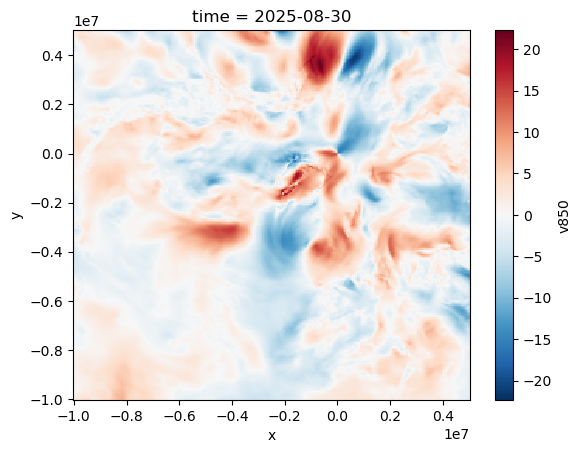

In [49]:
ds.isel(time=-1).v850.plot()


In [53]:
num_samples = all_days.size//256
k=0
# write_variable_year('u',850,256*k, 256*(k+1), R, mode='w')
for k in tqdm(range(37, num_samples+1)):
    overwrite_variable_year('v',850,256*k, 256*(k+1), R, mode='a')
    

  0%|          | 0/86 [00:00<?, ?it/s]

NameError: name 'R' is not defined

# Rotate winds


In [71]:
def rotate_east_north_to_npstereo_xy(u_e, v_n, longitude, longitude0_deg=0.0):
    """
    u_e, v_n: DataArrays on (latitude, longitude) or (y, x) with 'longitude' coord in degrees
    longitude: 2D longitudegitude array (same shape as u/v), degrees
    """
    # wrap (longitude - longitude0) to (-180, 180]
    dlongitude = (longitude - longitude0_deg + 180.0) % 360.0 - 180.0
    theta = np.deg2rad(dlongitude)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    u_x = cos_t * u_e - sin_t * v_n
    v_y = sin_t * u_e + cos_t * v_n
    return u_x, v_y

x,y = rotate_east_north_to_npstereo_xy(ds.u850, ds.v850, ds.lon)
chunks = (256, 64,64)

# Write metadata + array definition (no chunks) so dims are recorded
enc = {'x850': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks},
       'y850': {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
ds_ = xr.Dataset(dict(x850=x, y850=y)).transpose('time','y','x')
ds_.to_zarr(zarr_out, mode='a', 
            encoding=enc)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [70]:
ds_

<xarray.Dataset> Size: 33GB
Dimensions:  (y: 256, x: 256, time: 31289)
Coordinates:
  * y        (y) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06
  * x        (x) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06
    lat      (y, x) float64 524kB dask.array<chunksize=(64, 64), meta=np.ndarray>
    lon      (y, x) float64 524kB dask.array<chunksize=(64, 64), meta=np.ndarray>
  * time     (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
Data variables:
    x850     (y, x, time) float64 16GB dask.array<chunksize=(64, 64, 256), meta=np.ndarray>
    y850     (y, x, time) float64 16GB dask.array<chunksize=(64, 64, 256), meta=np.ndarray>

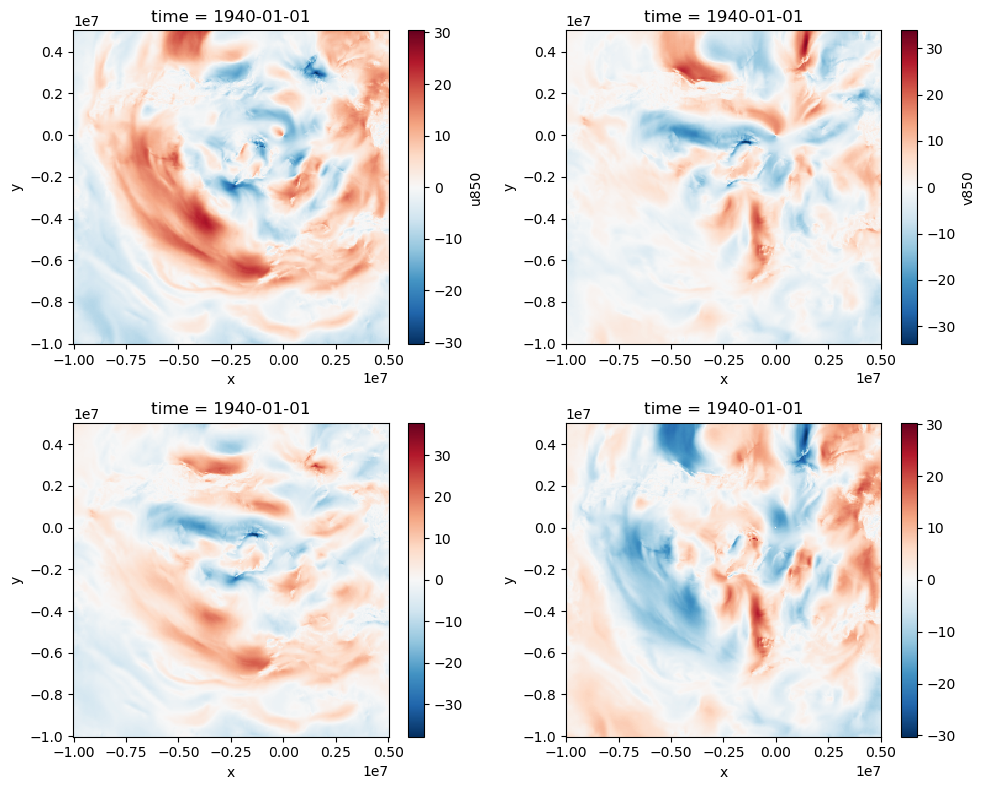

In [65]:
fig, axs = plt.subplots(2,2,figsize=(10,8))
ds.u850.isel(time=0).plot(ax=axs[0,0])
ds.v850.isel(time=0).plot(ax=axs[0,1])
x.isel(time=0).plot(ax=axs[1,0])
y.isel(time=0).plot(ax=axs[1,1])
plt.tight_layout()

# Download the first variable

In [10]:
num_samples = all_days.size//256
k=0
# write_variable_year('u',850,256*k, 256*(k+1), R, mode='w')
for k in tqdm(range(58, num_samples+1)):
    overwrite_variable_year('tcwv','surface',256*k, 256*(k+1), R, mode='a')


  0%|          | 0/8 [00:00<?, ?it/s]

2025-12-08 14:08:32,877 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-60c88d3b415b741fd39065c3a975212d', 99))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-12-08 14:08:32,877 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-60c88d3b415b741fd39065c3a975212d', 53))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-12-08 14:08:32,878 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-60c88d3b415b741fd39065c3a975212d', 12))" coro=<Worker.execute() done,

KeyboardInterrupt: 

# Make decoy variables for the rest

In [ ]:
# create empty variable for ERA5 Africa project

import zarr, numcodecs, xarray as xr, numpy as np
import dask.array as da

zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/ERA5_daily_africa_newproject.zarr"
base = xr.open_zarr(zarr_out, chunks={})
T    = base.sizes['time']
Nlat = base.sizes['latitude']
Nlon = base.sizes['longitude']

new_vars = ['u700', 'u850', 'v700', 'v850', 'z700', 'z850',
            'q700', 'q850', 'T700', 'T850', 'msl', 'pwat', 'omega500']

for variable in new_vars:
    # Build an empty dask array with your desired chunks (no data written)
    chunks = (256, Nlat, Nlon)
    arr = da.empty((T, Nlat, Nlon), chunks=chunks, dtype='float32')

    # Wrap as DataArray with correct dims & coords
    da_v = xr.DataArray(
        arr,
        dims=('time', 'latitude', 'longitude'),
        coords={'time':      base['time'].values,
                'latitude':  base['latitude'].values,
                'longitude': base['longitude'].values},
        name=variable
    )

    # Write metadata + array definition (no chunks) so dims are recorded
    enc = {variable: {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
    da_v.to_dataset().to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronou

In [ ]:
day_index_start=0
day_index_end=256
variable='v'
level=850
regridder=R 

da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
var_name = variable if level == 'surface' else f"{variable}{level}"
da = da.rename(var_name)
enc = dict() 

# First write creates store; subsequent years append along time
ds = da.to_dataset().drop_vars(['lon','lat'])
ds.v850.to_zarr(zarr_out, mode='a', 
            region={"time": slice(day_index_start, day_index_end)}, 
            encoding=enc)


ValueError: when setting `region` explicitly in to_zarr(), all variables in the dataset to write must have at least one dimension in common with the region's dimensions ['time'], but that is not the case for some variables here. To drop these variables from this dataset before exporting to zarr, write: .drop_vars(['x', 'y'])

In [34]:
ds.v850.to_zarr(zarr_out, mode='a', 
            region={"time": slice(day_index_start, day_index_end),
                    "x": slice(0,256),"y":slice(0,256)}, 
            encoding=enc)


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 64.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


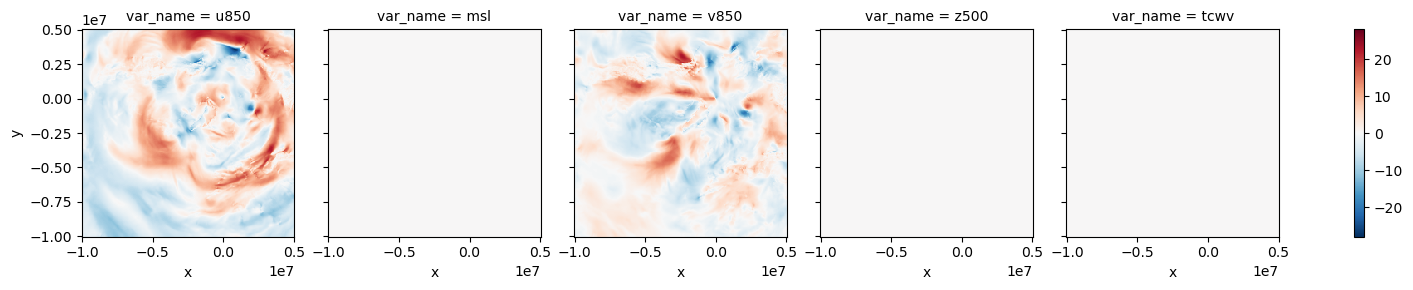

In [42]:
ds = xr.open_zarr(zarr_out,   consolidated=True)
ds.isel(time=300).to_array('var_name').plot(col='var_name')

  0%|          | 0/123 [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 64.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and

KeyboardInterrupt: 

2025-09-26 17:33:02,477 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 25))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-09-26 17:33:02,477 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 22))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-09-26 17:33:02,484 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 42))" coro=<Worker.execute() done,

 name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 15))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-09-26 17:33:02,500 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 18))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2025-09-26 17:33:02,501 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('from_sequence-open_daily_variable-24e293689aeaf9bc0792af249c33d842', 68))" coro=<Worker.execute() done, defined at /Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/worker_

In [41]:
ds = xr.open_zarr(zarr_out,   consolidated=True)

In [ ]:
import zarr
z = zarr.open("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_50km_1940-2024_NPS.zarr", mode="a")
# for v in ["u850", "v850", 'z500', 'tcwv']:
#     if v in z:
#         del z[v]

In [58]:
chunks = {'time': 256, 'y': 64, 'x': 64}  # ~year per chunk; 

enc = {'u850': {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['y'], chunks['x'])},
           "y": {"compressor": compressor}, "x": {"compressor": compressor}, "time": {"compressor": compressor}}


ds_u = xr.DataArray(z['u850'][:],dims=['time','x','y'], coords=dict(time=pd.date_range('1940-01-01', periods=z['u850'][:].shape[0], freq='D'),
                                                        x=z['x'][:], y=z['y'][:]))
ds_u.to_zarr(zarr_out, mode='w', encoding=enc)                                                    

KeyError: 'u850'

In [13]:
for k in z.keys():
    print(k)

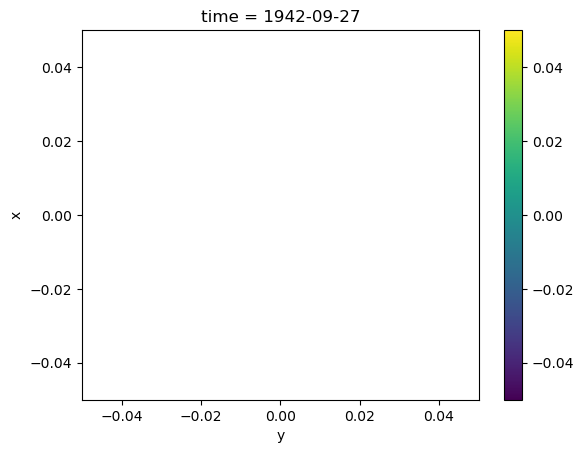

In [62]:
ds_u.isel(time=1000).plot()

In [ ]:
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_50km_1940-2024_NPS.zarr"


<xarray.DataArray (time: 31289, x: 256, y: 256)> Size: 8GB
array([[[-7.499203  , -7.1319394 , -6.713549  , ..., -5.4417152 ,
         -5.387668  , -5.431387  ],
        [-6.860699  , -6.4303746 , -5.9925494 , ..., -6.3535395 ,
         -6.4046245 , -6.37289   ],
        [-6.071895  , -5.6989555 , -5.2629404 , ..., -6.487231  ,
         -6.593147  , -6.5565596 ],
        ...,
        [-4.434539  , -4.247209  , -4.0504007 , ...,  4.286688  ,
          4.4316897 ,  4.4953833 ],
        [-4.5960464 , -4.418486  , -4.249817  , ...,  5.2266245 ,
          5.3615704 ,  5.5654955 ],
        [-4.705055  , -4.5593195 , -4.4230456 , ...,  6.3298593 ,
          6.2324967 ,  6.3276505 ]],

       [[-5.6605124 , -5.395942  , -5.2504206 , ..., -4.107196  ,
         -3.7820437 , -3.7049267 ],
        [-5.456949  , -5.4274964 , -5.3902817 , ..., -4.687253  ,
         -4.569784  , -4.5320835 ],
        [-5.5774794 , -5.5611567 , -5.552637  , ..., -5.066129  ,
         -5.0000024 , -4.9736867 ],
...
         -0.28968313, -1.1043173 ],
        [ 0.47621548,  0.51108444,  0.5641772 , ..., -0.30346912,
         -1.0352879 , -1.7198306 ],
        [ 0.47472054,  0.28995436,  0.098543  , ..., -0.97660357,
         -1.5992768 , -2.1430852 ]],

       [[-7.406251  , -7.152353  , -7.2533145 , ..., -3.2167354 ,
         -3.4866178 , -3.483705  ],
        [-7.6031065 , -7.6802487 , -7.7055206 , ..., -3.1381013 ,
         -3.386342  , -3.352101  ],
        [-8.028942  , -8.207183  , -8.330551  , ..., -3.0349114 ,
         -3.1679394 , -3.1016634 ],
        ...,
        [-2.219738  , -1.4415578 , -0.90260375, ...,  0.32865468,
         -0.31312537, -0.63946444],
        [-2.5821996 , -1.8567668 , -1.3659546 , ..., -0.16605364,
         -0.65074605, -0.8201383 ],
        [-2.8929398 , -2.2794962 , -1.8242296 , ..., -0.639103  ,
         -0.94654465, -1.0829718 ]]],
      shape=(31289, 256, 256), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 250kB 1940-01-01 1940-01-02 ... 2025-08-30
  * x        (x) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06
  * y        (y) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06

In [53]:
ds_u.to_zarr(zarr_out, mode='a', encoding={})

KeyError: 'Zarr object is missing the `dimension_names` metadata which is required for xarray to determine variable dimensions.'

In [32]:
# z['time'] = z['time'][:31289]
z['time'] = pd.date_range('1940-01-01', '2024-12-31', freq='D').values[:31289]

In [42]:
zarr.consolidate_metadata(zarr_out)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


<Group file:///Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024_NPS.zarr>

In [45]:
base = xr.open_zarr(zarr_out,   consolidated=True)


KeyError: 'Zarr object is missing the `dimension_names` metadata which is required for xarray to determine variable dimensions.'

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


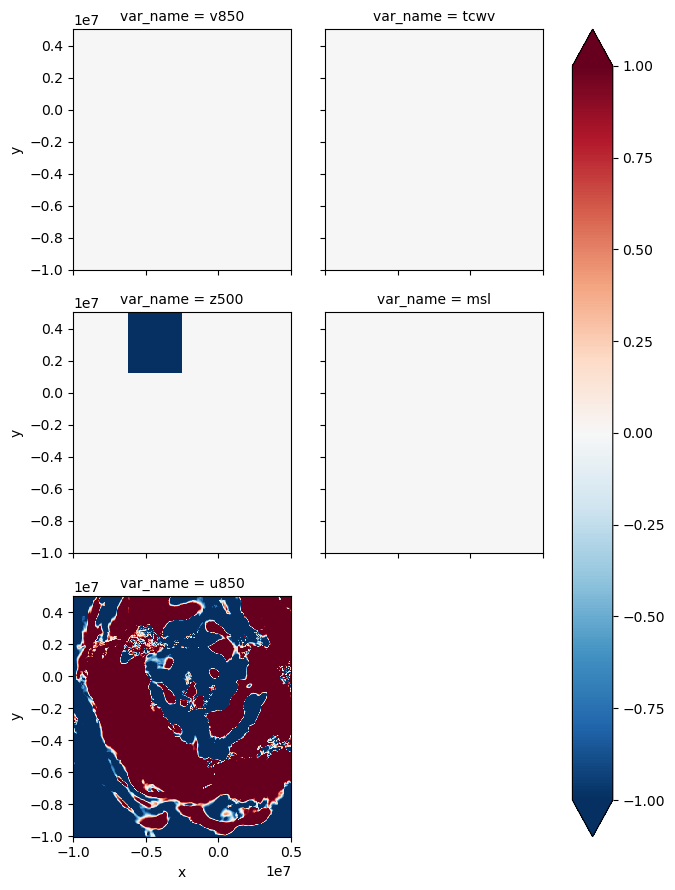

In [17]:
base = xr.open_zarr(zarr_out, chunks={})
base.isel(time=0).to_array('var_name').plot(col='var_name', col_wrap=2, vmax=1)

# Download other variables

In [ ]:
num_samples = all_days.size//256
for k in tqdm(range(0, num_samples+1)):
    write_variable_year('v',850,256*k, 256*(k+1), R, mode='a')

  0%|          | 0/123 [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 65.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and

KeyboardInterrupt: 

2025-09-26 14:17:44,292 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/asyncio/base_events.py", line 687, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/asyncio/locks.py", line 212, in wait
    await fut
asyncio.e

In [ ]:
ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_50km_1940-2024_NPS.zarr")
ds
# ds_mean = ds.mean('time').load()
# ds_std = ds.std('time').load()
# ds_mean = ds_mean.to_array('var_name').rename('mean_fields')
# ds_std = ds_std.to_array('var_name').rename('std_fields')

<xarray.Dataset> Size: 42GB
Dimensions:  (time: 31801, y: 256, x: 256)
Coordinates:
  * time     (time) datetime64[ns] 254kB 1940-01-01 1940-01-02 ... 2025-08-30
    lon      (y, x) float64 524kB dask.array<chunksize=(64, 64), meta=np.ndarray>
    lat      (y, x) float64 524kB dask.array<chunksize=(64, 64), meta=np.ndarray>
  * x        (x) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06
  * y        (y) float64 2kB -1e+07 -9.941e+06 -9.882e+06 ... 4.941e+06 5e+06
Data variables:
    z500     (time, y, x) float32 8GB dask.array<chunksize=(256, 64, 64), meta=np.ndarray>
    v850     (time, y, x) float32 8GB dask.array<chunksize=(256, 256, 256), meta=np.ndarray>
    tcwv     (time, y, x) float32 8GB dask.array<chunksize=(256, 256, 256), meta=np.ndarray>
    u850     (time, y, x) float32 8GB dask.array<chunksize=(256, 256, 256), meta=np.ndarray>
    msl      (time, y, x) float32 8GB dask.array<chunksize=(256, 256, 256), meta=np.ndarray>

In [73]:
ds_mean.to_zarr(zarr_out, mode= 'a',)
ds_std.to_zarr(zarr_out, mode= 'a',)


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [75]:
ds

<xarray.Dataset> Size: 21GB
Dimensions:      (time: 31289, latitude: 91, longitude: 360, var_name: 5)
Coordinates:
  * longitude    (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time         (time) datetime64[ns] 250kB 1940-01-01 ... 2025-08-30
  * latitude     (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name     (var_name) object 40B 'u850' 'v850' 'tcwv' 'z500' 'msl'
Data variables:
    v850         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    u850         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    msl          (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    tcwv         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    mean_fields  (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>
    z500         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    std_fields   (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>

In [69]:
ds_mean

<xarray.Dataset> Size: 659kB
Dimensions:    (latitude: 91, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    u850       (latitude, longitude) float32 131kB -0.002525 ... -6.794
    v850       (latitude, longitude) float32 131kB 0.002618 0.002618 ... -0.3237
    tcwv       (latitude, longitude) float32 131kB 5.252 5.252 ... 44.97 44.58
    z500       (latitude, longitude) float32 131kB 5.123e+04 ... 5.738e+04
    msl        (latitude, longitude) float32 131kB 1.014e+05 ... 1.009e+05

<xarray.DataArray (var_name: 5, latitude: 91, longitude: 360)> Size: 655kB
dask.array<getitem, shape=(5, 91, 360), dtype=float32, chunksize=(1, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
    time       datetime64[ns] 8B 2022-12-05
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'tcwv' 'z500' 'msl'

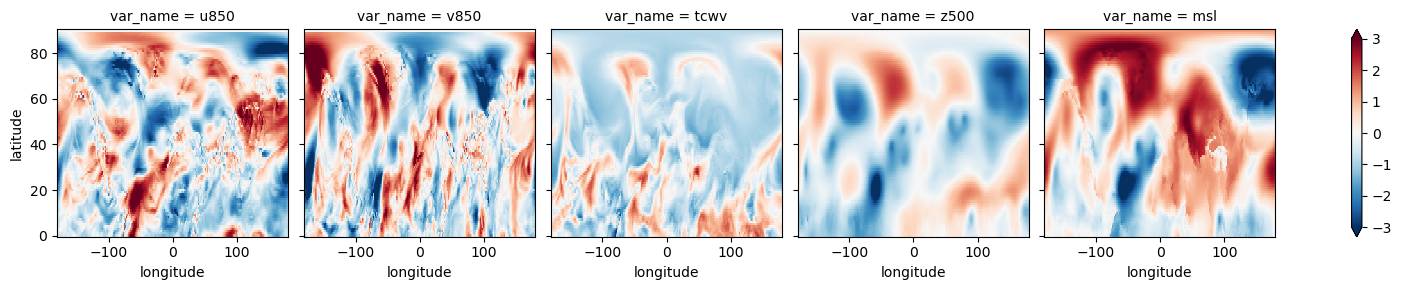

In [64]:
# ds_array = /
# ds_norm = (ds_array - ds_array.mean('time'))/ds_array.std('time')
ds_norm = ((ds - ds_mean)/ds_std).to_array('var_name').isel(time=-1000)
ds_norm.plot(col='var_name', vmax=3)
ds_norm

In [16]:
first_variable = True

variable = 'u'
level =850

sample_ds = open_sample_ds(all_days[0], variable, level)
R = build_regridder(sample_ds, target_grid=target_grid, method='bilinear')    


num_samples = all_days.size//256

### RERUN THiS FOR OTHER VAribaLES
for k in tqdm(range( num_samples, num_samples+1)):
    da_v = get_data_batch(256*k, 256*(k+1),'v', '850', R)
    da_tc = get_data_batch(256*k, 256*(k+1),'tcwv', 'surface', R)
    da_z = get_data_batch(256*k, 256*(k+1),'z', '500', R)
    da_msl = get_data_batch(256*k, 256*(k+1),'msl', 'surface', R)
    da_v = da_v.rename('v850').astype('float32') 
    da_tc = da_tc.rename('tcwv').astype('float32') 
    da_z = da_z.rename('z500').astype('float32') 
    da_msl = da_msl.rename('msl').astype('float32') 
    region = {'time': slice(256*k, 256*(k+1)),'latitude':slice(0,91), 'longitude':slice(0, 360)}
    # enc = {'z500': {"compressor":compressor}}
    enc = dict()
    da_v.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_tc.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_z.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_msl.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    # ds.to_array('var_name').mean('time').plot(col='var_name')

/tmp/ipykernel_3607308/827316853.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  src_nlat, src_nlon = s.dims['latitude'], s.dims['longitude']
/tmp/ipykernel_3607308/827316853.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgt_nlat, tgt_nlon = target_grid.dims['latitude'], target_grid.dims['longitude']


  0%|          | 0/1 [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronou

In [ ]:
region = {'time': slice(0, 256),'latitude':slice(0,91), 'longitude':slice(0, 360)}
enc = {'v850': {"compressors":compressor}}
da_v0.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/core/group.py:2552: UserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 63.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [18]:
ds.close()

In [24]:
ds.isel(time=-1)#.to_array('var_name').plot(col='var_name')

<xarray.Dataset> Size: 659kB
Dimensions:    (latitude: 91, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
    time       datetime64[ns] 8B 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    u850       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    v850       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    msl        (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    tcwv       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    z500       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>

In [27]:
ds = xr.open_zarr(zarr_out)

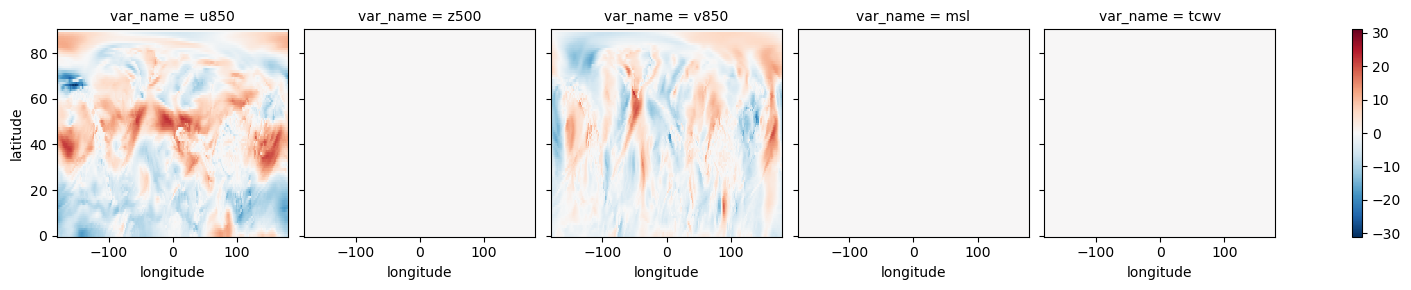

In [30]:
ds.isel(time=12394).to_array('var_name').plot(col='var_name')

In [ ]:

R = build_regridder(sample_ds, var_key=variable, level=level, target_grid=target_grid, method='bilinear')    
years = range(all_days[0].year, all_days[-1].year + 1)
first_year_for_this_var = True

y = years[0]


NameError: name 'all_days' is not defined

In [ ]:
write_variable_year(variable, level, y, R,
                    mode=('w' if first_variable and first_year_for_this_var else 'a'))

In [ ]:
first_variable = True
for variable, level in vars_levels:
    # Pick a sample day that exists (just take the first)
    sample_ds = open_sample_ds(all_days[0], variable, level)
    # Choose regridding method: bilinear safe for u/v/T/z/msl/tcwv
    R = build_regridder(sample_ds, var_key=variable, level=level, target_grid=target_grid, method='bilinear')    
    # Stream by year to keep graphs modest
    years = range(all_days[0].year, all_days[-1].year + 1)
    first_year_for_this_var = True
    for y in tqdm(years):
        write_variable_year(variable, level, y, R,
                            mode=('w' if first_variable and first_year_for_this_var else 'a'))
        first_year_for_this_var = False
    first_variable = False

# Consolidate metadata once
xr.backends.zarr.consolidate_metadata(zarr_out)

# -----------------------
# Optional: add normalized variables into the SAME store
#   data_normed = (X - mu) / sigma, where
#   mu = global mean over time
#   sigma = weighted std over lon, lat, time (weights = cos(lat))
# -----------------------
ds = xr.open_zarr(zarr_out, chunks=chunks)

# Compute grand mean per var
mu = ds.mean('time').compute()

# Weighted std across (lon, lat, time)
# broadcast weights over lon/time
w = np.cos(np.deg2rad(ds.lat)).astype('float32')
w = w / w.mean()  # optional normalization of weights
std = ( (ds - mu).weighted(w).std(dim=('lon','lat','time')) ).compute()

ds_norm = xr.Dataset(
    data_vars=dict(
        data_normed=((ds - mu) / std).astype('float32'),
        mean_value=mu.astype('float32'),
        std_value=std.astype('float32'),
    ),
    coords=dict(time=ds.time, lat=ds.lat, lon=ds.lon)
)

enc_norm = {
    "data_normed": {"compressor": compressor, "dtype": "float32"},
    "mean_value":  {"compressor": compressor, "dtype": "float32"},
    "std_value":   {"compressor": compressor, "dtype": "float32"},
    "lat": {"compressor": compressor}, "lon": {"compressor": compressor}, "time": {"compressor": compressor}
}

ds_norm.to_zarr(zarr_out, mode='a', encoding=enc_norm)
xr.backends.zarr.consolidate_metadata(zarr_out)

# -----------------------
# Reading hint (if you prefer -180..180 longitudes for training)
# -----------------------
# ds_train = xr.open_zarr(zarr_out)
# ds_train = ds_train.assign_coords(lon=((ds_train.lon + 180) % 360)).sortby('lon')

/tmp/ipykernel_3232622/3972593739.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  src_nlat, src_nlon = s.dims['lat'], s.dims['lon']
/tmp/ipykernel_3232622/3972593739.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgt_nlat, tgt_nlon = target_grid.dims['lat'], target_grid.dims['lon']
